In [1]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = pd.read_csv(url, names=columns)
df.head()

NameError: name 'pd' is not defined

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]
df = pd.read_csv("iris.csv",names=columns)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
print("--- Feature Information ---")
print(df.info())
print("\nFeature Types:")
print(df.dtypes)

--- Feature Information ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Feature Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class               str
dtype: object


In [16]:
df.groupby('class')['sepal_length'].mean()

class
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: sepal_length, dtype: float64

In [17]:
df.groupby('class').agg(['mean', 'median', 'min', 'max', 'std'])

sepal_length                            sepal_width         \
                        mean median  min  max       std        mean median   
class                                                                        
Iris-setosa            5.006    5.0  4.3  5.8  0.352490       3.418    3.4   
Iris-versicolor        5.936    5.9  4.9  7.0  0.516171       2.770    2.8   
Iris-virginica         6.588    6.5  4.9  7.9  0.635880       2.974    3.0   

                                    petal_length                             \
                 min  max       std         mean median  min  max       std   
class                                                                         
Iris-setosa      2.3  4.4  0.381024        1.464   1.50  1.0  1.9  0.173511   
Iris-versicolor  2.0  3.4  0.313798        4.260   4.35  3.0  5.1  0.469911   
Iris-virginica   2.2  3.8  0.322497        5.552   5.55  4.5  6.9  0.551895   

                petal_width                             
                       mean median  min  max       std  
class                                                   
Iris-setosa           0.244    0.2  0.1  0.6  0.107210  
Iris-versicolor       1.326    1.3  1.0  1.8  0.197753  
Iris-virginica        2.026    2.0  1.4  2.5  0.274650

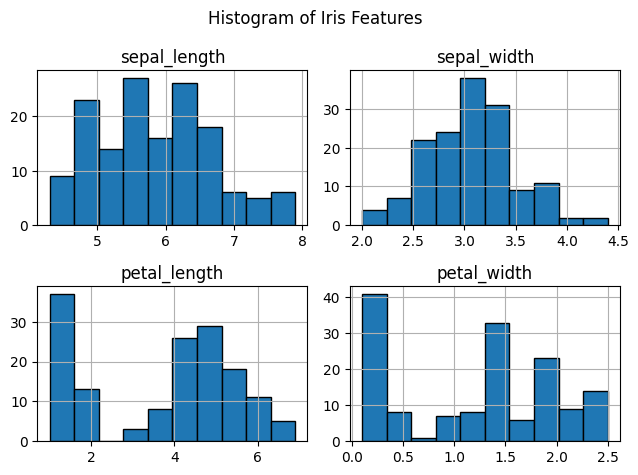

In [18]:
# Requirement 2: Histograms for each feature
# We use a subplot layout for better visualization
#df.hist(figsize=(10, 8), bins=15, edgecolor='black')
df.hist(edgecolor='black')
plt.suptitle("Histogram of Iris Features")
plt.tight_layout()

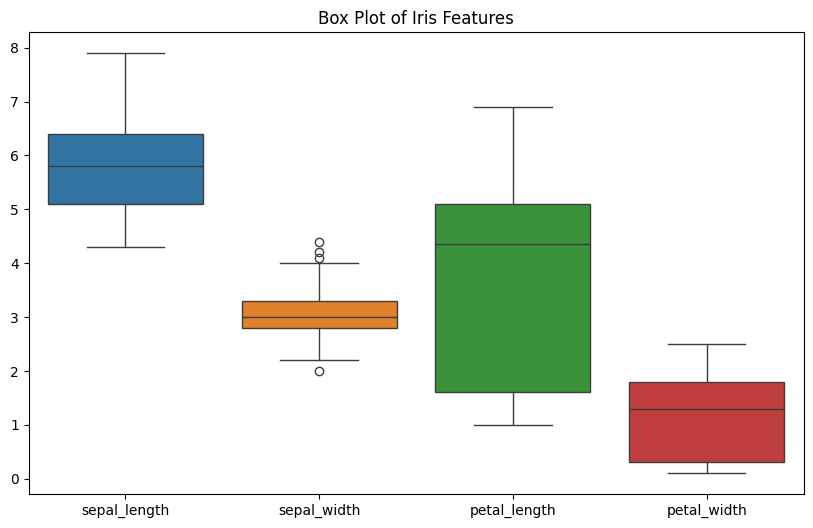

In [19]:
# Requirement 3: Box plots for each feature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Box Plot of Iris Features")
plt.show()

Text(0.5, 1.0, 'Sepal Width by Species (Check for Outliers)')

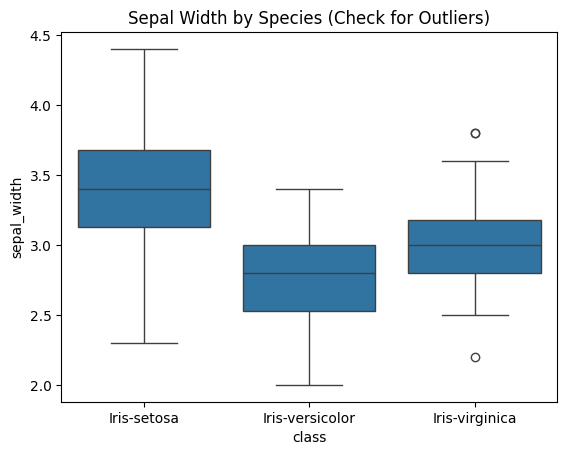

In [20]:
# Requirement 4: Compare distributions by Species (to identify patterns/outliers)
sns.boxplot(x='class', y='sepal_width', data=df)
plt.title("Sepal Width by Species (Check for Outliers)")



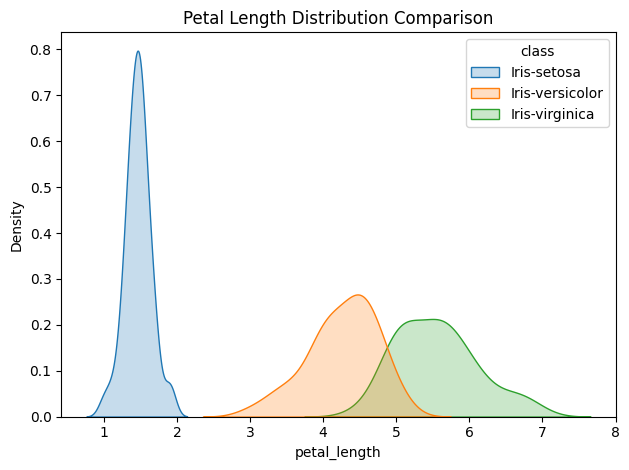

In [21]:
sns.kdeplot(data=df, x='petal_length', hue='class', fill=True)
plt.title("Petal Length Distribution Comparison")

plt.tight_layout()
plt.show()

In [23]:
# Ultra-simplified Outlier Check
for col in ["sepal_length", "sepal_width", "petal_length", "petal_width"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"\nFeature: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


Feature: sepal_length


NameError: name 'lower_bound' is not defined

In [24]:
for column in df.drop(columns=["class"]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(outliers)
    print(f"\nFeature: {column}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


Empty DataFrame
Columns: [sepal_length, sepal_width, petal_length, petal_width, class]
Index: []

Feature: sepal_length
Lower Bound: 3.15
Upper Bound: 8.35
Number of Outliers: 0
    sepal_length  sepal_width  petal_length  petal_width            class
15           5.7          4.4           1.5          0.4      Iris-setosa
32           5.2          4.1           1.5          0.1      Iris-setosa
33           5.5          4.2           1.4          0.2      Iris-setosa
60           5.0          2.0           3.5          1.0  Iris-versicolor

Feature: sepal_width
Lower Bound: 2.05
Upper Bound: 4.05
Number of Outliers: 4
Empty DataFrame
Columns: [sepal_length, sepal_width, petal_length, petal_width, class]
Index: []

Feature: petal_length
Lower Bound: -3.65
Upper Bound: 10.35
Number of Outliers: 0
Empty DataFrame
Columns: [sepal_length, sepal_width, petal_length, petal_width, class]
Index: []

Feature: petal_width
Lower Bound: -1.95
Upper Bound: 4.05
Number of Outliers: 0


In [26]:
group=df.groupby("class").agg(['mean', 'median', 'min', 'max', 'std'])
group

sepal_length                            sepal_width         \
                        mean median  min  max       std        mean median   
class                                                                        
Iris-setosa            5.006    5.0  4.3  5.8  0.352490       3.418    3.4   
Iris-versicolor        5.936    5.9  4.9  7.0  0.516171       2.770    2.8   
Iris-virginica         6.588    6.5  4.9  7.9  0.635880       2.974    3.0   

                                    petal_length                             \
                 min  max       std         mean median  min  max       std   
class                                                                         
Iris-setosa      2.3  4.4  0.381024        1.464   1.50  1.0  1.9  0.173511   
Iris-versicolor  2.0  3.4  0.313798        4.260   4.35  3.0  5.1  0.469911   
Iris-virginica   2.2  3.8  0.322497        5.552   5.55  4.5  6.9  0.551895   

                petal_width                             
                       mean median  min  max       std  
class                                                   
Iris-setosa           0.244    0.2  0.1  0.6  0.107210  
Iris-versicolor       1.326    1.3  1.0  1.8  0.197753  
Iris-virginica        2.026    2.0  1.4  2.5  0.274650